In [1]:
import os
import torch
import numpy as np
import pandas as pd
from epiweeks import Week
import seaborn as sns
import preprocess_data as prep
import model as mc
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

columns_to_normalize = ['casos','epiweek', 'biome', 'enso']

predict_n = 36
max_epiweek = 16
    
boxcox = False

TEST_YEAR = 2026

In [2]:
batch_size = 1
doenca = 'chikungunya'
min_delta = 0.0
patience= 20
lr = 5e-4
min_year = 2015
model_name = 'enso_media_2'

filename = f'./data/{doenca}.csv.gz'

df = prep.load_cases_data(filename)

df = df.loc[df.epiweek <= int(f'{TEST_YEAR}{max_epiweek}')]

enso = prep.load_enso_weekly()

enso_neutro = prep.load_enso_weekly(filename='data/enso_weekly_neutro.csv')

In [3]:
df

,geocode,casos,epiweek,uf,macroregional_geocode,regional_geocode,uf_code,target_city,train_1,target_1,train_2,target_2,train_3,target_3,train_4,target_4,disease
date,,,,,,,,,,,,,,,,,
2013-12-29,1200013,0.0,201401,AC,1201,12002,12,False,True,False,True,False,True,False,True,False,chikungunya
2013-12-29,2310258,0.0,201401,CE,2310,23001,23,False,True,False,True,False,True,False,True,False,chikungunya
2013-12-29,4202107,0.0,201401,SC,4211,42017,42,False,True,False,True,False,True,False,True,False,chikungunya
2013-12-29,4202099,0.0,201401,SC,4213,42001,42,False,True,False,True,False,True,False,True,False,chikungunya
2013-12-29,2310308,0.0,201401,CE,2307,23024,23,False,True,False,True,False,True,False,True,False,chikungunya
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,3527900,0.0,202616,SP,3533,35092,35,False,False,False,False,False,False,False,False,True,chikungunya
2026-04-19,3102902,0.0,202616,MG,3102,31013,31,False,False,False,False,False,False,False,False,True,chikungunya
2026-04-19,2514701,0.0,202616,PB,2501,25006,25,False,False,False,False,False,False,False,False,True,chikungunya


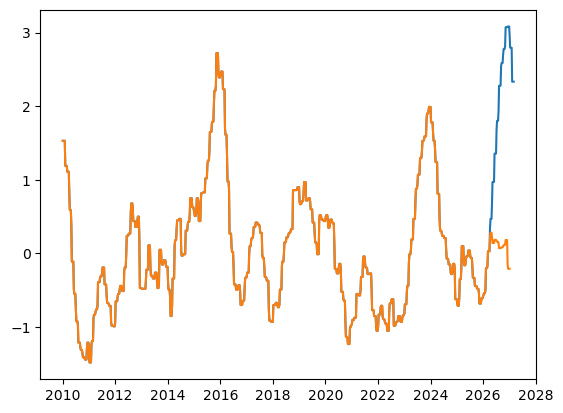

In [4]:
_,ax = plt.subplots()

ax.plot(enso.index, enso.enso )

ax.plot(enso_neutro.index, enso_neutro.enso )

Sul
Sudeste
Nordeste
Centro-Oeste
Norte


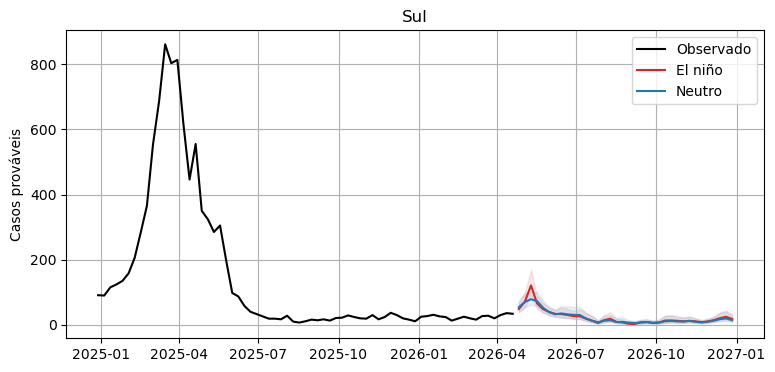

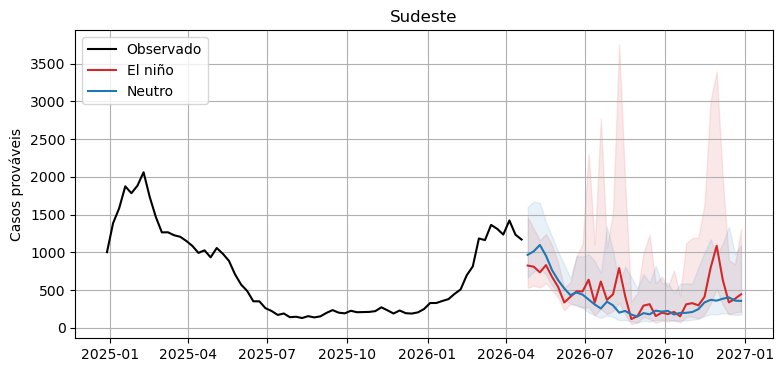

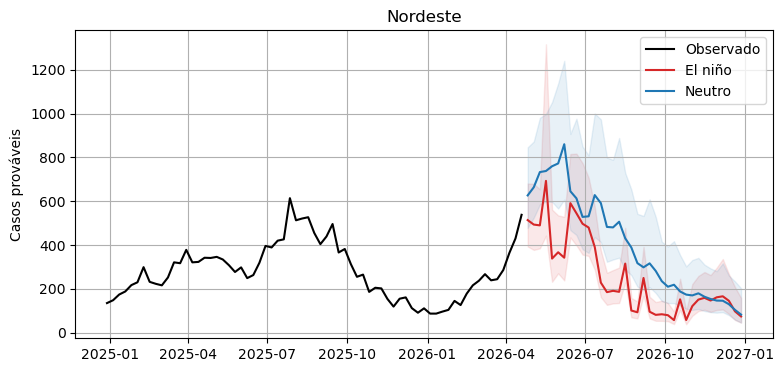

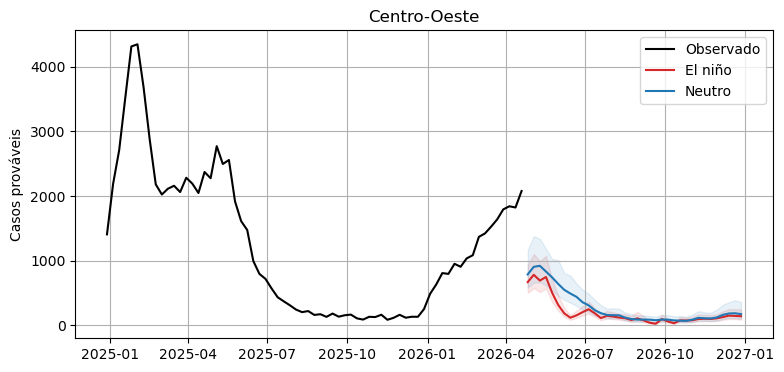

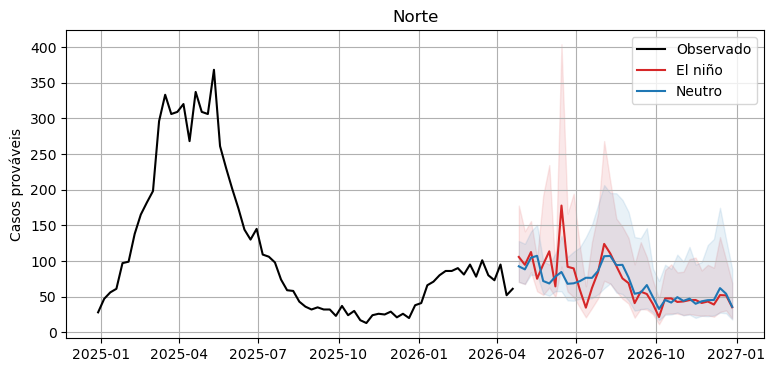

In [5]:
for region in regioes_estados.keys(): 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    model = mc.LSTMWithFutureCovariatesV2(

                    hidden=64,

                    past_features=5,

                    future_cov_size=predict_n,

                    predict_n=predict_n,

                    dropout=0.2
                        )
    
    model_path = f'./saved_models/trained_{doenca}_{region}_{TEST_YEAR-1}_{model_name}.pt'
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)  
        
    

    filename_el_nino = f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_forecast_{model_name}.csv'

    if os.path.exists(filename_el_nino):
        df_preds = pd.read_csv(filename_el_nino)
        df_preds.date = pd.to_datetime(df_preds.date)
    else:
        df_preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                        max_epiweek = max_epiweek,
                                        boxcox = boxcox,
                                        n_passes = 500,
                                        min_year= min_year, media = True)

            
        df_preds.to_csv(filename_el_nino)

    filename_neutro = f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv'

    if os.path.exists(filename_neutro):
        df_preds_neutro = pd.read_csv(filename_neutro)
        df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)
    else:

        df_preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                        max_epiweek = max_epiweek,
                                        boxcox = boxcox,
                                        n_passes = 500,
                                        min_year= min_year, media = True)

            
        df_preds_neutro.to_csv(filename_neutro)


    _, ax = plt.subplots(figsize = (9,4))

    df_st_plot = df_reg.loc[(df_reg.epiweek >= 202501)]

    df_st_plot = df_st_plot.resample('W-SUN')[['casos']].sum()

    ax.plot(df_st_plot.index, df_st_plot.casos, color = 'black', label = 'Observado')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:blue', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:blue', alpha = 0.1)

    ax.set_title(region)
    ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.grid()
    #ax.set_ylim([0, 3600])

    plt.savefig(f'figures/forecast_{doenca}_{region}_{model_name}.png', dpi = 400, bbox_inches = 'tight')     

Make figures: 

In [6]:
def make_figure(ax, df, region, TEST_YEAR, model_name): 

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_forecast_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)


    df_st_plot = df_reg.loc[(df_reg.epiweek >= 202501)]

    df_st_plot = df_st_plot.resample('W-SUN')[['casos']].sum()

    ax.plot(df_st_plot.index, df_st_plot.casos, color = 'black', label = 'Observado')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:blue', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:blue', alpha = 0.1)

    ax.set_title(region)
    ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.grid()


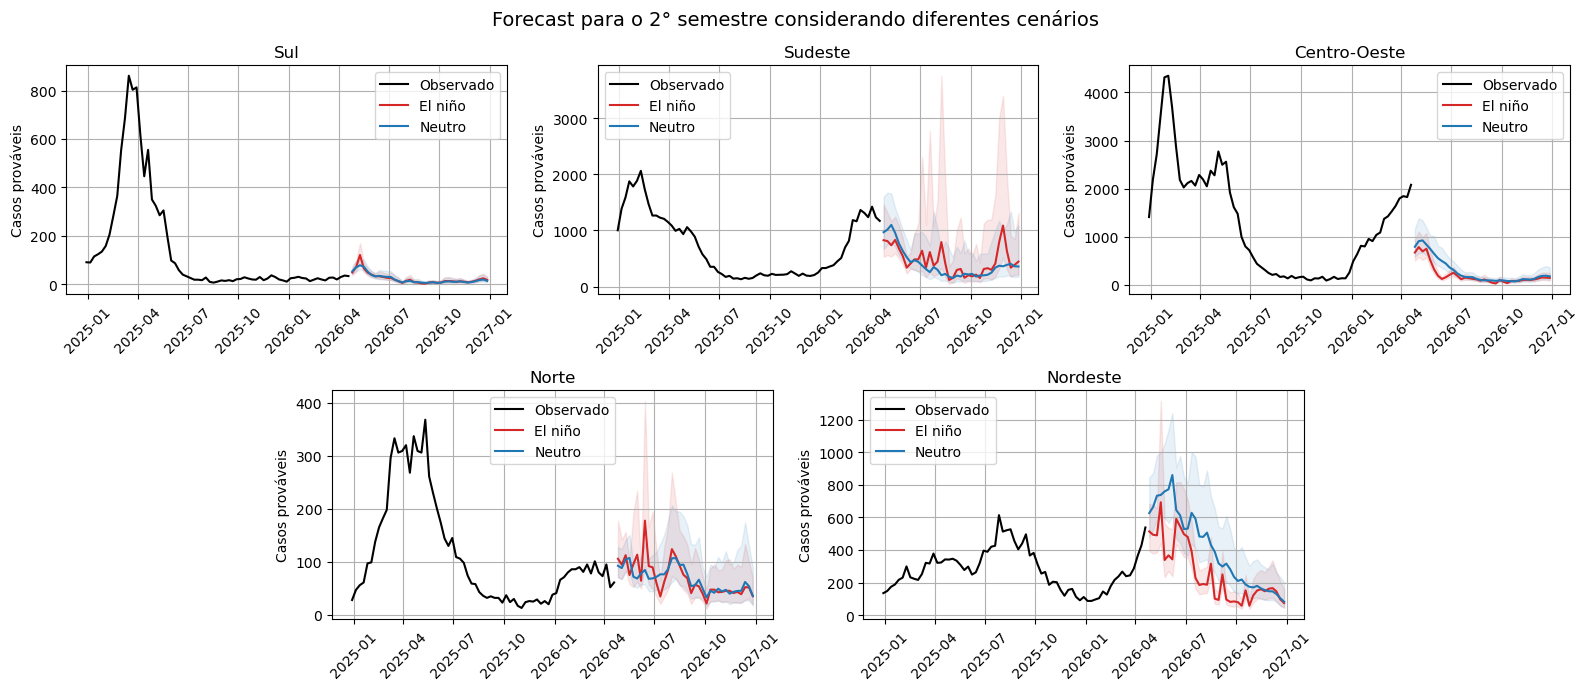

In [7]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])


for r, ax in zip(['Sul', 'Sudeste', 'Centro-Oeste', 'Norte', 'Nordeste'], [ax1,ax2,ax3,ax4,ax5]): 

    make_figure(ax, df, r, TEST_YEAR, 'enso_media_2')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Forecast para o 2° semestre considerando diferentes cenários', fontsize = 14)
plt.tight_layout()

plt.savefig(f'forecast_all_regions_{doenca}_enso_median_2.png', dpi = 400, bbox_inches = 'tight')
plt.show()

In [8]:
def make_figure2(ax, df, region, TEST_YEAR, model_name): 

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_forecast_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)

    df_st_plot = df_reg.resample('W-SUN')[['casos']].sum()
    df_st_plot['year'] = df_st_plot.index.year
    df_st_plot['week'] = [Week.fromdate(x).week for x in df_st_plot.index]

    for year in np.arange(2020, 2026):

        df_reg_y = df_st_plot.loc[(df_st_plot.year == year) & (df_st_plot.week >= 17) & (df_st_plot.week <= 52)]
        
        ax.plot(df_preds.date, df_reg_y.casos, color = 'black', alpha = 0.25)

    ax.plot([], [], color = 'black', alpha = 0.25, label = '2020-2025')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:blue', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:blue', alpha = 0.1)

    ax.set_title(region)
    #ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.set_ylim([0, 1.25*max( df_preds.upper_80)])

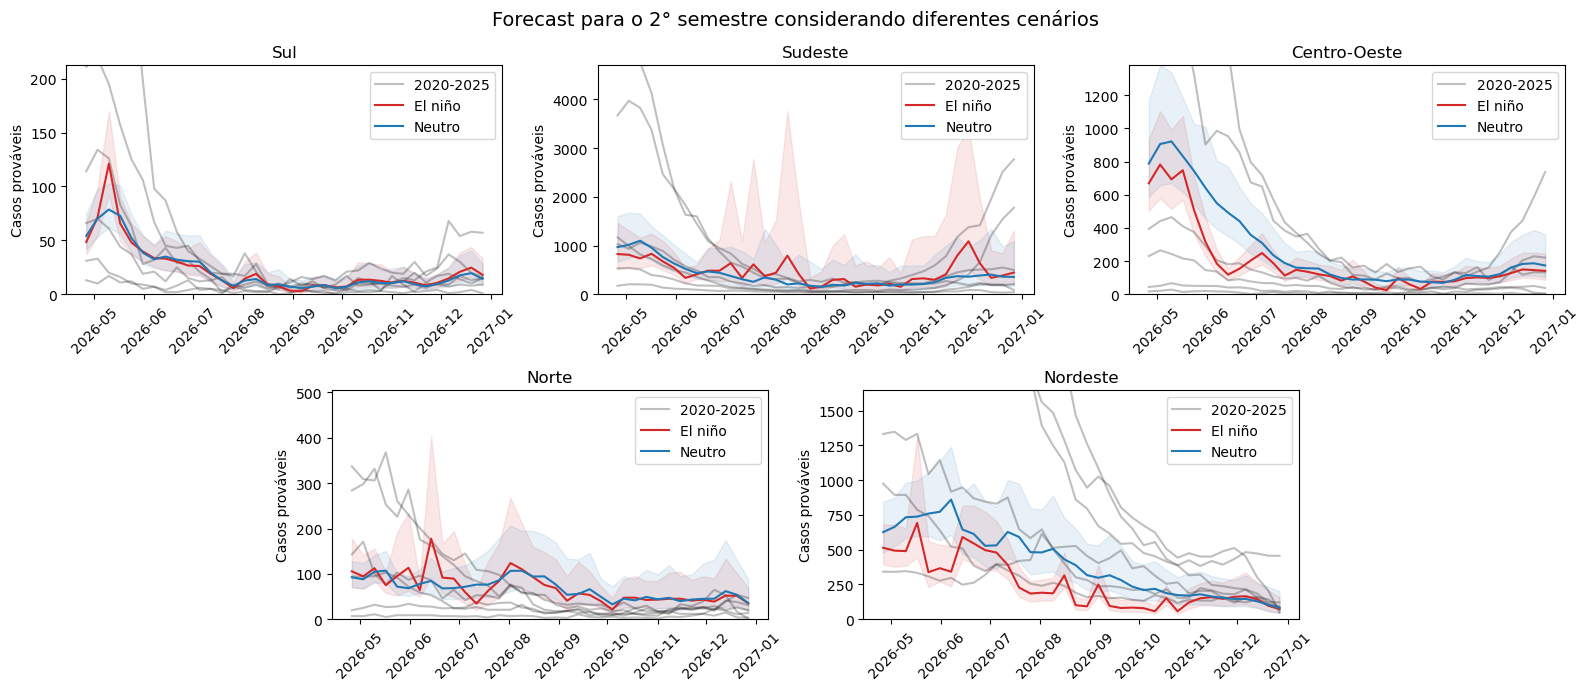

In [9]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])


for r, ax in zip(['Sul', 'Sudeste', 'Centro-Oeste', 'Norte', 'Nordeste'], [ax1,ax2,ax3,ax4,ax5]): 

    make_figure2(ax, df, r, TEST_YEAR, 'enso_media_2')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Forecast para o 2° semestre considerando diferentes cenários', fontsize = 14)
plt.tight_layout()

plt.savefig(f'forecast_all_regions_{doenca}_2_semester_enso_median_2.png', dpi = 400, bbox_inches = 'tight')
plt.show()

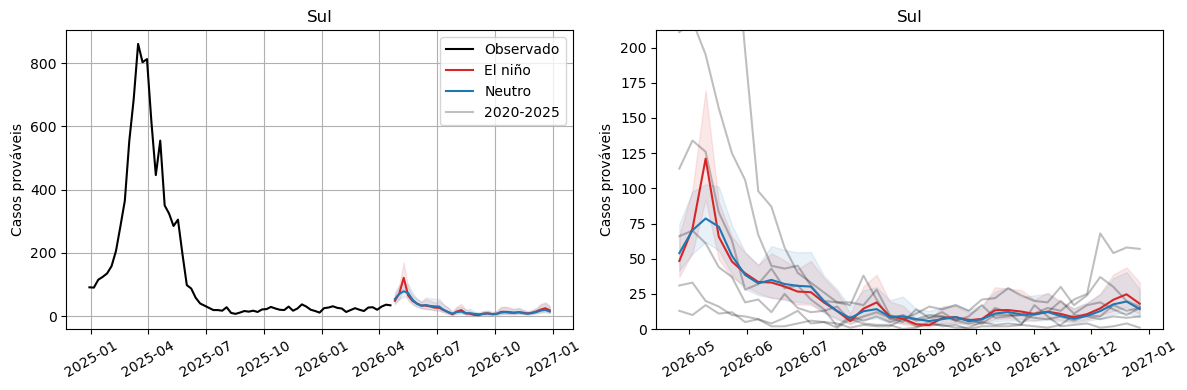

In [10]:
_,ax = plt.subplots(1,2, figsize = (12, 4), sharey = False)
r = 'Sul'
make_figure(ax[0], df, r, TEST_YEAR, 'enso_media_2')
ax[0].tick_params(axis='x', rotation=30)

make_figure2(ax[1], df, r, TEST_YEAR, 'enso_media_2')
ax[1].tick_params(axis='x', rotation=30)


handles1, labels1 = ax[0].get_legend_handles_labels()
handles2, labels2 = ax[1].get_legend_handles_labels()

# combina
handles = handles1 + handles2
labels = labels1 + labels2

# remove duplicados preservando ordem
unique = dict(zip(labels, handles))

# cria legenda única
ax[0].legend(unique.values(), unique.keys(), loc="best")


plt.tight_layout()
plt.show()

### Total cases: 

In [11]:
df_end = pd.DataFrame()
for region in regioes_estados.keys(): 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    model = mc.LSTMWithFutureCovariatesV2(

                    hidden=64,

                    past_features=5,

                    future_cov_size=predict_n,

                    predict_n=predict_n,

                    dropout=0.2
                        )
    
    model_path = f'./saved_models/trained_{doenca}_{region}_{TEST_YEAR-1}_{model_name}.pt'
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)  
        
    
    preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                    max_epiweek = max_epiweek,
                                    boxcox = boxcox,
                                    n_passes = 500,
                                    min_year= min_year, media = True, return_samples= True)
    

    df_sum_el_nino = mc.get_total_cases(preds, region, model_name= 'El niño')


    preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                    max_epiweek = max_epiweek,
                                    boxcox = boxcox,
                                    n_passes = 500,
                                    min_year= min_year, media = True, return_samples=True)
    
    df_sum_neutro = mc.get_total_cases(preds_neutro, region, model_name= 'Neutro')

    
    df_end = pd.concat([df_end, df_sum_el_nino, df_sum_neutro], ignore_index= True)



Sul
Sudeste
Nordeste
Centro-Oeste
Norte


In [12]:
df_end.head()

,region,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,model
0,Sul,919.819369,857.143790,999.390575,805.783936,1090.222144,775.709985,1136.965102,758.829552,1178.362781,El niño
1,Sul,894.601846,824.211386,972.791688,775.419887,1045.039159,746.842682,1101.647129,732.941491,1131.696358,Neutro
2,Sudeste,25245.153461,21378.038733,32025.860212,18719.708344,43789.678881,17726.880048,58652.444363,17028.661026,78300.174655,El niño
3,Sudeste,19634.974800,17382.632469,22597.215946,15788.846697,27239.527124,15217.961590,33551.228514,14472.928186,39884.386592,Neutro
4,Nordeste,9853.328005,9245.469205,10662.183137,8812.604553,11436.705925,8541.149838,12018.495517,8336.836623,12684.416286,El niño


In [13]:
df_end.to_csv(f'predictions/total_cases_all_regions_{doenca}_enso_media_2.csv', index = False)

In [14]:
df_end = pd.read_csv(f'predictions/total_cases_all_regions_{doenca}_enso_media_2.csv'
                     
                     )

df_end.head()

,region,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,model
0,Sul,919.819369,857.143790,999.390575,805.783936,1090.222144,775.709985,1136.965102,758.829552,1178.362781,El niño
1,Sul,894.601846,824.211386,972.791688,775.419887,1045.039159,746.842682,1101.647129,732.941491,1131.696358,Neutro
2,Sudeste,25245.153461,21378.038733,32025.860212,18719.708344,43789.678881,17726.880048,58652.444363,17028.661026,78300.174655,El niño
3,Sudeste,19634.974800,17382.632469,22597.215946,15788.846697,27239.527124,15217.961590,33551.228514,14472.928186,39884.386592,Neutro
4,Nordeste,9853.328005,9245.469205,10662.183137,8812.604553,11436.705925,8541.149838,12018.495517,8336.836623,12684.416286,El niño


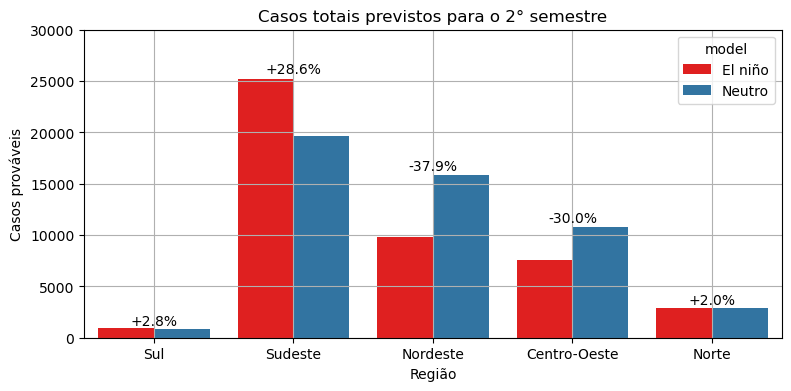

In [18]:
_,ax = plt.subplots(figsize = (9, 4))

sns.barplot(data=df_end, ax=ax, hue='model', x='region', y = 'pred', palette=['red', 'tab:blue'])

for i, region in enumerate(df_end['region'].unique()):

    df_r = df_end[df_end['region'] == region]

    v1 = df_r.loc[df_r.model == 'Neutro']['pred'].values[0]
    v2 = df_r.loc[df_r.model == 'El niño']['pred'].values[0]

    pct = 100 * (v2 - v1) / v1

    y = max(v1, v2)

    ax.text(
        i,                  # centro do grupo
        y * 1.01,           # um pouco acima da barra mais alta
        f'{pct:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


#ax.set_ylim([0, 210000])
ax.set_ylim([0, 30000])

ax.grid()
ax.set_xlabel('Região')
ax.set_ylabel('Casos prováveis')
ax.set_title('Casos totais previstos para o 2° semestre')
plt.savefig(f'total_cases_all_regions_{doenca}.png', dpi = 400, bbox_inches = 'tight')
plt.show()